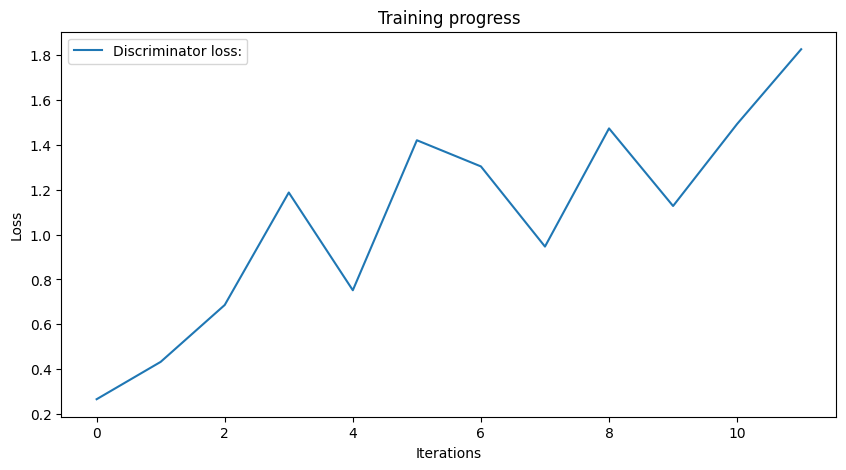

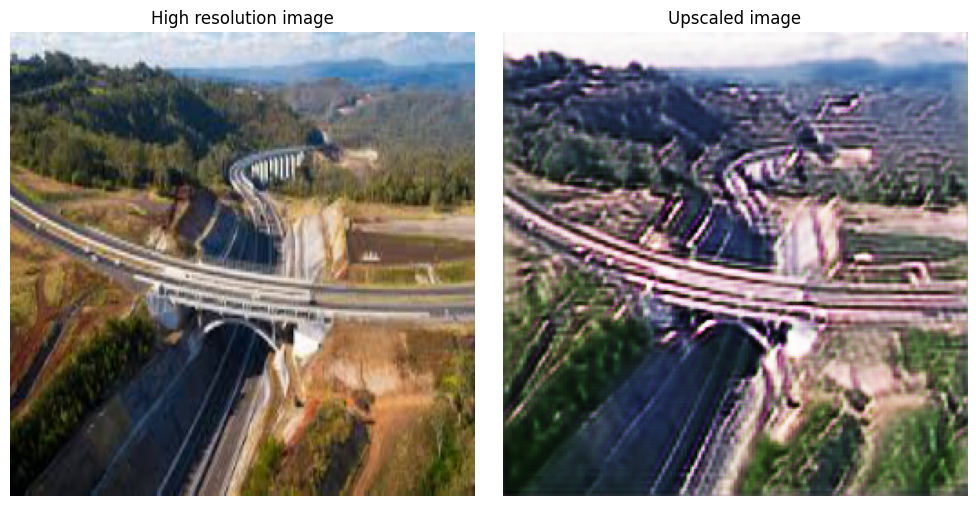

Perceptual Loss: 0.8840357065200806


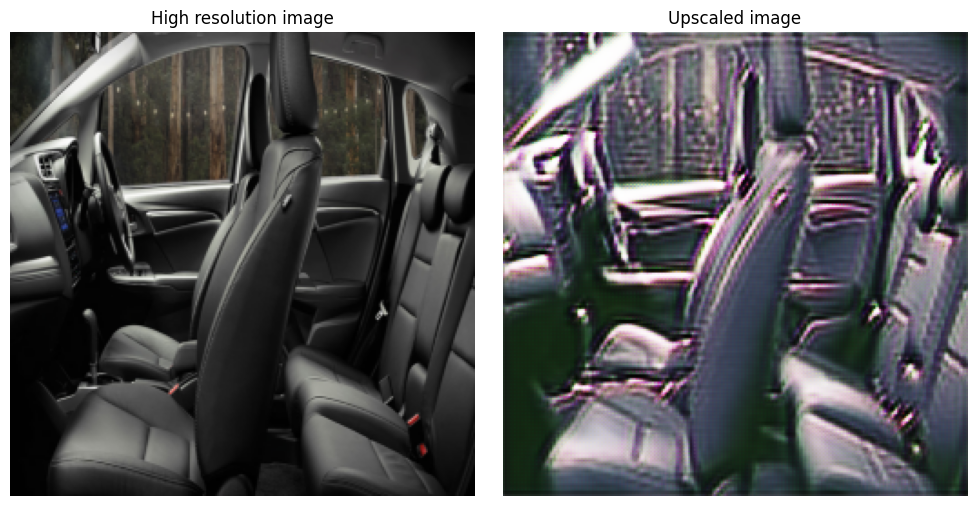

Average PSNR: 14.44453239440918
Average SSIM: 0.7419416904449463


error: OpenCV(4.13.0) /io/opencv/modules/imgproc/src/color.cpp:199: error: (-215:Assertion failed) !_src.empty() in function 'cvtColor'


In [ ]:
import os
import numpy as np
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import cv2
import matplotlib.pyplot as plt
import random
import torch.nn as nn
from torchvision.models import vgg19
import torch
from torch import optim
from tqdm.notebook import tqdm
import torchvision.transforms as transforms
!pip install torch-summary
from torchsummary import summary
from torchvision.transforms import ToPILImage
import kagglehub

# Download latest version and define 'path'
path = kagglehub.dataset_download("adityachandrasekhar/image-super-resolution")

# Define the transformations on the data
low_res_size = 128
high_res_size = 256

transform_low = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((low_res_size, low_res_size)),
    transforms.ToTensor(),
])

transform_high = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((high_res_size, high_res_size)),
    transforms.ToTensor(),
])
class ImageDataset(Dataset):
    # This is a custom dataset created using pytorch Dataset
    def __init__(self, root_dir):
        super(ImageDataset, self).__init__()
        self.data = []
        self.root_dir = root_dir
        files_low = os.listdir(os.path.join(root_dir, "low_res"))
        files_high = os.listdir(os.path.join(root_dir, "high_res"))
        self.data = list(zip(files_low, files_high))


    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        img_low_file, img_high_file = self.data[index]

        # Get the path for the image LR and HR
        low_res_pth = os.path.join(self.root_dir, "low_res", img_low_file)
        high_res_pth = os.path.join(self.root_dir, "high_res", img_high_file)

        # Open the actual image
        low_res = np.array(Image.open(low_res_pth))
        high_res = np.array(Image.open(high_res_pth))

        # Discarding the alpha channel to make the model more optimized for memory
        low_res = low_res[:, :, :3]
        high_res = high_res[:, :, :3]

        # Apply the transformation to the image
        low_res = transform_low(low_res)
        high_res = transform_high(high_res)

        return low_res, high_res
    
# Showing an image from the dataset
def show_image():
    # Use the 'path' variable to dynamically get the dataset root directory
    dataset = ImageDataset(root_dir=os.path.join(path, "dataset", "train"))
    loader = DataLoader(dataset, batch_size=128, num_workers=4)
    # Create a figure with two subplots
    fig, axs = plt.subplots(1, 2, figsize=(8, 4))
    for idx, (low_res, high_res) in enumerate(loader):
        # Display the first image in the left subplot
        axs[0].imshow(low_res[0].permute(1, 2, 0))
        axs[0].set_title("low res")

        # Display the second image in the right subplot
        axs[1].imshow(high_res[0].permute(1, 2, 0))
        axs[1].set_title("high res")

        if(idx == 0):
            break

    # Show the figure
    plt.show()
device = "cuda" if torch.cuda.is_available() else "cpu"
lr = 3e-4
epochs = 12
batch_size = 10
num_workers = 2
img_channels = 3
# listing the model to take the required subset of it
test_vgg_model = vgg19(weights=True).eval().to(device)
lf = list(test_vgg_model.features)
for idx, layer in enumerate(lf):
    print(f"Layer {idx}: {layer}")
class vggL(nn.Module):
    def __init__(self):
        super().__init__()
        self.vgg = vgg19(pretrained=True).features[:25].eval().to(device)
        self.loss = nn.MSELoss()

    def forward(self, first, second):
        vgg_first = self.vgg(first)
        vgg_second = self.vgg(second)
        perceptual_loss = self.loss(vgg_first, vgg_second)
        return perceptual_loss
class ConvBlock(nn.Module):
    # Conv -> BN -> leakyReLU

    def __init__(
            self,
            in_channels,
            out_channels,
            use_activation=True,
            use_BatchNorm=True,
            **kwargs
    ):

        super().__init__()
        self.use_activation = use_activation
        self.cnn = nn.Conv2d(in_channels, out_channels, **kwargs)
        self.bn = nn.BatchNorm2d(out_channels) if use_BatchNorm else nn.Identity()
        self.ac = (
            nn.LeakyReLU(0.2, inplace=True)
        )

    def forward(self, x):
        x1 = self.cnn(x)
        x2 = self.bn(x1)
        x3 = self.ac(x2)
        return x3 if self.use_activation else x2

class UpsampleBlock(nn.Module):
    def __init__(self, in_channels, scale_factor):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, in_channels * scale_factor ** 2, 2, 1, 1)
        self.ps = nn.PixelShuffle(scale_factor)
        self.ac = nn.PReLU(num_parameters=in_channels)

    def forward(self, x):
        return self.ac(self.ps(self.conv(x)))

class ResidualBlock(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.b1 = ConvBlock(
            in_channels,
            in_channels,
            kernel_size=3,
            stride=1,
            padding=1
        )

        self.b2 = ConvBlock(
            in_channels,
            in_channels,
            kernel_size=3,
            stride=1,
            padding=1,
            use_activation=False
        )

    def forward(self, x):
        out = self.b1(x)
        out = self.b2(out)
        return out + x
class Generator(nn.Module):
    def __init__(self, in_channels=3, num_channels=64, num_blocks=16):
        super().__init__()
        self.initial = ConvBlock(in_channels, num_channels, kernel_size=7, stride=1, padding=4, use_BatchNorm=False)
        self.res = nn.Sequential(*[ResidualBlock(num_channels) for i in range(num_blocks)])
        self.conv = ConvBlock(num_channels, num_channels, kernel_size=3, stride=1, padding=1, use_activation=False)
        self.up = nn.Sequential(UpsampleBlock(num_channels, scale_factor=2))
        self.final = nn.Conv2d(num_channels, in_channels, kernel_size=9, stride=1, padding=1)

    def forward(self, x):
        x = self.initial(x)
        c = self.res(x)
        c = self.conv(c) + x
        c = self.up(c)
        return torch.sigmoid(self.final(c))

class Discriminator(nn.Module):
    def __init__(self, in_channels=3, features=[64, 64, 128, 128, 256, 256, 512, 512]):
        super().__init__()
        blocks = []
        for idx, feature in enumerate(features):
            blocks.append(
                ConvBlock(
                    in_channels,
                    feature,
                    kernel_size=3,
                    stride = idx % 2 + 1,
                    padding=1,
                    use_activation=True,
                    use_BatchNorm=idx != 0,
                )
            )
            in_channels = feature

        self.blocks = nn.Sequential(*blocks)

        self.mlp = nn.Sequential(
            nn.AdaptiveAvgPool2d((8, 8)),
            nn.Flatten(),
            nn.Linear(512*8*8, 1024),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(1024, 1)
        )

    def forward(self, x):
        x = self.blocks(x)
        x = self.mlp(x)
        return x
generator = Generator(in_channels=3, num_channels=64, num_blocks=16)
discriminator = Discriminator(in_channels=3, features=[64, 64, 128, 128, 256, 256, 512, 512])

input_size = (3, 256, 256)

print("Generator Summary:")
summary(generator, input_size)

print("\nDiscriminator Summary:")
summary(discriminator, input_size)
def plot_examples(gen):
    dataset_test = ImageDataset(root_dir=os.path.join(path, "dataset", "train"))
    loader = DataLoader(dataset_test, batch_size=16, num_workers=2)

    # Create a figure with two subplots
    fig, axs = plt.subplots(1, 3, figsize=(8, 4))
    chosen_batch = random.randint(0, len(loader)-1)
    for idx, (low_res, high_res) in enumerate(loader):
        if(chosen_batch == idx):
            chosen = random.randint(0, len(low_res)-1)

            axs[0].set_axis_off()
            axs[0].imshow(low_res[chosen].permute(1, 2, 0))
            axs[0].set_title("low res")

            with torch.no_grad():
                upscaled_img = gen(low_res[chosen].to(device).unsqueeze(0))

            axs[1].set_axis_off()
            axs[1].imshow(upscaled_img.cpu().permute(0, 2, 3, 1)[0])
            axs[1].set_title("predicted")

            axs[2].set_axis_off()
            axs[2].imshow(high_res[chosen].permute(1, 2, 0))
            axs[2].set_title("high res")

            if(idx == 1):
                break

    # Show the figure
    plt.show()

    gen.train()
from IPython.display import clear_output
import matplotlib.pyplot as plt

def train_progress(epoch, num_epochs, d_losses, g_losses):
    clear_output(wait=True)
    plt.figure(figsize=(10,5))
    plt.title("Training progress")
    plt.plot(d_losses,label="Discriminator loss")
    plt.plot(g_losses,label="Generator loss")
    plt.xlabel("Iterations")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

    print(f"Epoch [{epoch}/{num_epochs}], Discriminator loss: {d_losses[-1]:.4f}, Generator loss: {g_losses[-1]:.4f}")
# define the generator / discriminator / and other hyperparameters (not already defined above)
gen = Generator(in_channels=3).to(device)
disc = Discriminator(in_channels=3).to(device)
opt_gen = optim.Adam(gen.parameters(), lr=lr, betas=(0.9, 0.999))
opt_disc = optim.Adam(disc.parameters(), lr=lr, betas=(0.9, 0.999))
mse = nn.MSELoss()
bce = nn.BCEWithLogitsLoss()
vgg_loss = vggL()
# the data loaders for training and validation
train = ImageDataset(root_dir=os.path.join(path, "dataset", "train"))
train_loader = DataLoader(train, batch_size=batch_size, num_workers=num_workers)

val = ImageDataset(root_dir=os.path.join(path, "dataset", "val"))
val_loader = DataLoader(val, batch_size=batch_size, num_workers=num_workers)
def train_fn(loader, disc, gen, opt_gen, opt_disc, mse, bce, vgg_loss):
    loop = tqdm(train_loader)
    disc_loss = 0
    gen_loss = 0

    for idx, (low_res, high_res) in enumerate(loop):
        high_res = high_res.to(device)
        low_res = low_res.to(device)

        ### Train Discriminator: max log(D(x)) + log(1 - D(G(z)))
        fake = gen(low_res)

        disc_real = disc(high_res)
        disc_fake = disc(fake.detach())

        disc_loss_real = bce(disc_real, torch.ones_like(disc_real))
        disc_loss_fake = bce(disc_fake, torch.zeros_like(disc_fake))

        disc_loss = disc_loss_fake + disc_loss_real

        opt_disc.zero_grad()
        disc_loss.backward()
        opt_disc.step()

        # Train Generator: min log(1 - D(G(z))) <-> max log(D(G(z))
        disc_fake = disc(fake)
        adversarial_loss = 1e-3 * bce(disc_fake, torch.ones_like(disc_fake))
        loss_for_vgg = 0.006 * vgg_loss(fake, high_res)
        gen_loss = loss_for_vgg + adversarial_loss

        opt_gen.zero_grad()
        gen_loss.backward()
        opt_gen.step()

    return gen_loss.detach().cpu(), disc_loss.detach().cpu()
#run once
d_losses = []
g_losses = []
i = 0
epochs = 12
for epoch in range(epochs):
    plot_examples(gen)
    print("epoch ", i, "/", epochs)
    gen_loss, disc_loss = train_fn(train_loader, disc, gen, opt_gen, opt_disc, mse, bce, vgg_loss)
    print('Gen loss: ', gen_loss, ', Disc loss: ', disc_loss)
         # train discriminator and generator and update losses
    d_losses.append(disc_loss)
    g_losses.append(gen_loss)
    i = i + 1
    if i > 12:
        savedir = '/kaggle/working/' + str(i) + '/'
        os.mkdir(savedir)
        torch.save(gen.state_dict(), savedir + "checkpoint1_gen")
        torch.save(disc.state_dict(), savedir + "checkpoint1_disc")
def plot_generated(gen):
    dataset_test = ImageDataset(root_dir=os.path.join(path, "dataset", "val"))
    loader = DataLoader(dataset_test, batch_size=16, num_workers=2)

    # Create a figure with two subplots
    fig, axs = plt.subplots(1, 3, figsize=(15, 10))
    chosen_batch = random.randint(0, len(loader)-1)
    for idx, (low_res, high_res) in enumerate(loader):
        if(chosen_batch == idx):
            chosen = random.randint(0, len(low_res)-1)

            axs[0].set_axis_off()
            axs[0].imshow(low_res[chosen].permute(1, 2, 0))
            axs[0].set_title("low res")

            with torch.no_grad():
                upscaled_img = gen(low_res[chosen].to(device).unsqueeze(0))

            axs[1].set_axis_off()
            axs[1].imshow(upscaled_img.cpu().permute(0, 2, 3, 1)[0])
            axs[1].set_title("predicted")

            axs[2].set_axis_off()
            axs[2].imshow(high_res[chosen].permute(1, 2, 0))
            axs[2].set_title("high res")

            if(idx == 1):
                break

    # Show the figure
    plt.show()
plot_generated(gen)
def train_progress2(epoch, num_epochs, d_losses, g_losses):
    clear_output(wait=True)
    plt.figure(figsize=(10,5))
    plt.title("Training progress")
    plt.plot(g_losses,label="Generator loss")
    plt.xlabel("Iterations")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

#     print(f"Epoch [{epoch}/{num_epochs}], Discriminator loss: {d_losses[-1]:.4f}, Generator loss: {g_losses[-1]:.4f}")
train_progress2(epoch, 5, d_losses, g_losses)
def train_progress3(epoch, num_epochs, d_losses, g_losses):
    clear_output(wait=True)
    plt.figure(figsize=(10,5))
    plt.title("Training progress")
    plt.plot(d_losses,label="Discriminator loss:")
    plt.xlabel("Iterations")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

#     print(f"Epoch [{epoch}/{num_epochs}], Discriminator loss: {d_losses[-1]:.4f}, Generator loss: {g_losses[-1]:.4f}")
train_progress3(epoch, 5, d_losses, g_losses)
import cv2
import matplotlib.pyplot as plt
from torchvision.transforms.functional import to_pil_image

def get_high_res_and_prediction(gen):
    dataset_test = ImageDataset(root_dir=os.path.join(path, "dataset", "val"))
    loader = DataLoader(dataset_test, batch_size=16, num_workers=2)

    chosen_batch = random.randint(0, len(loader)-1)
    for idx, (low_res, high_res) in enumerate(loader):
        if(chosen_batch == idx):
            chosen = random.randint(0, len(low_res)-1)

            low_res_img = low_res[chosen].unsqueeze(0).to(device)
            high_res_img = high_res[chosen]

            with torch.no_grad():
                upscaled_img = gen(low_res_img)
                upscaled_img = upscaled_img.cpu().squeeze(0)

            # Hiển thị 2 ảnh
            plt.figure(figsize=(10, 5))
            plt.subplot(1, 2, 1)
            plt.imshow(to_pil_image(high_res_img))
            plt.title("High resolution image")
            plt.axis('off')

            plt.subplot(1, 2, 2)
            plt.imshow(to_pil_image(upscaled_img))
            plt.title("Upscaled image")
            plt.axis('off')

            plt.tight_layout()
            plt.show()

            return high_res_img, upscaled_img
vggL_model = vggL().to(device)
high_res_img, upscaled_img = get_high_res_and_prediction(gen)
high_res_img = high_res_img.unsqueeze(0).to(device)
upscaled_img = upscaled_img.unsqueeze(0).to(device)
loss_function = vggL_model(high_res_img, upscaled_img)
print("Perceptual Loss:", loss_function.item())
#Perceptual Loss: 0.536295473575592
import torch
import torch.nn.functional as F

def calculate_psnr(image1, image2):
    mse = F.mse_loss(image1, image2)
    psnr = 20 * torch.log10(1.0 / torch.sqrt(mse))
    return psnr.item()

calculate_psnr(high_res_img, upscaled_img)
import torch
import torch.nn.functional as F

def calculate_ssim(image1, image2):
    ssim = F.mse_loss(image1, image2, reduction='none')
    ssim = (2 * image1 * image2 + 1e-8) / (image1**2 + image2**2 + 1e-8)
    ssim = torch.mean(ssim)
    return ssim.item()

calculate_ssim(high_res_img, upscaled_img)
import torch
import torch.nn.functional as F
from torchvision.transforms.functional import to_pil_image
from torch.utils.data import DataLoader
import random
import matplotlib.pyplot as plt

def get_high_res_and_prediction(gen):
    dataset_test = ImageDataset(root_dir=os.path.join(path, "dataset", "val"))
    loader = DataLoader(dataset_test, batch_size=16, num_workers=2)

    total_psnr = 0
    total_ssim = 0
    num_samples = 0

    for idx, (low_res, high_res) in enumerate(loader):
        chosen_batch = random.randint(0, len(loader)-1)
        if chosen_batch != idx:
            continue

        chosen = random.randint(0, len(low_res)-1)

        low_res_img = low_res[chosen].unsqueeze(0).to(device)
        high_res_img = high_res[chosen]

        with torch.no_grad():
            upscaled_img = gen(low_res_img)
            upscaled_img = upscaled_img.cpu().squeeze(0)


        psnr = calculate_psnr(high_res_img, upscaled_img)
        ssim = calculate_ssim(high_res_img, upscaled_img)


        total_psnr += psnr
        total_ssim += ssim
        num_samples += 1


        plt.figure(figsize=(10, 5))
        plt.subplot(1, 2, 1)
        plt.imshow(to_pil_image(high_res_img))
        plt.title("High resolution image")
        plt.axis('off')

        plt.subplot(1, 2, 2)
        plt.imshow(to_pil_image(upscaled_img))
        plt.title("Upscaled image")
        plt.axis('off')

        plt.tight_layout()
        plt.show()


    avg_psnr = total_psnr / num_samples
    avg_ssim = total_ssim / num_samples

    return avg_psnr, avg_ssim

avg_psnr, avg_ssim = get_high_res_and_prediction(gen)
print("Average PSNR:", avg_psnr)
print("Average SSIM:", avg_ssim)
def upscaledimg(img):
    img = transform_low(img)
    print(img.shape)
    with torch.no_grad():
        upscaled_img = gen(img.to(device).unsqueeze(0))
    print(upscaled_img.shape)
    plt.imshow(upscaled_img.cpu().permute(0, 2, 3, 1)[0])
    return upscaled_img
import matplotlib.pyplot as plt
from skimage import data
from skimage import exposure
from skimage.exposure import match_histograms

def with_histogram_matching(img_source):
    upscaled_img = upscaledimg(img_source)
    upscaled_img = torch.reshape(upscaled_img, (3, 256, 256))
    upscaled_img = upscaled_img.cpu().permute(1, 2, 0).numpy()

    image = upscaled_img
    reference = img_source/255

    matched = match_histograms(image, reference ,
                           channel_axis=-1)


    fig, (ax1, ax2, ax3) = plt.subplots(nrows=1, ncols=3,
                                        figsize=(10, 10),
                                        sharex=True, sharey=True)

    for aa in (ax1, ax2, ax3):
        aa.set_axis_off()
    reference = cv2.resize(reference, (128, 128))
    reference = cv2.resize(reference, (256, 256))

    ax1.imshow(image)
    ax1.set_title('Generated image')
    ax2.imshow(reference)
    ax2.set_title('Low resolution image')
    ax3.imshow(matched)
    ax3.set_title('Matched')

    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(8, 8))

    for i, img in enumerate((image, reference, matched)):
        for c, c_color in enumerate(('red', 'green', 'blue')):
            img_hist, bins = exposure.histogram(img[..., c],
                                                source_range='dtype')
            axes[c, i].plot(bins, img_hist / img_hist.max())
            axes[c, i].set_ylim(0, 1)
            img_cdf, bins = exposure.cumulative_distribution(img[..., c])
            axes[c, i].plot(bins, img_cdf)
            axes[c, 0].set_ylabel(c_color)

    axes[0, 0].set_title('Generated image')
    axes[0, 1].set_title('Low resolution image')
    axes[0, 2].set_title('Matched')

    plt.tight_layout()
    plt.show()
    return matched
testing = cv2.imread('/kaggle/input/image-test/anhmau.jpg')
testing = cv2.cvtColor(testing, cv2.COLOR_BGR2RGB)
plt.imshow(testing)

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("adityachandrasekhar/image-super-resolution")

print("Path to dataset files:", path)

100%|██████████| 301M/301M [00:01<00:00, 198MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/adityachandrasekhar/image-super-resolution/versions/2
